In [16]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import matplotlib
import texplot
import matplotlib.colors as colors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
from pprint import pprint

import freealg
from freealg import AlgebraicForm
from freealg.visualization import domain_coloring, glue_branches, hist
from freealg.distributions import MarchenkoPastur, ChiralBlock, DeformedWigner, \
    DeformedMarchenkoPastur, CompoundFreePoisson, FreeLevy
from freealg.visualization import plot_flow, plot_mass, ridgeplot

plot_dir = './plots'

[(0.9984996249062267, 3.13165791447862), (4.157389347336835, 7.597674418604652)]


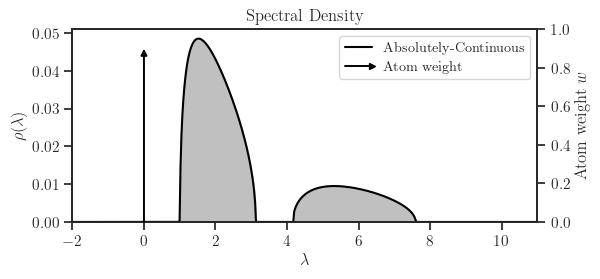

In [2]:
filename = 'algebraic-compound-poisson'
title = 'Compound Free Poisson'

lam = 0.1
t1 = 2.0
t2 = 5.5
w1 = 0.75

dist = CompoundFreePoisson(t=[t1, t2], w=[w1, 1-w1], lam=lam)
# dist = FreeLevy(t=[t1, t2], w=[w1, 1-w1], lam=lam, a=0.0, sigma=0.0)

# Support
support = dist.support()
print(support)

# Grid
x_min = numpy.floor(min(a for a, b in support) - 1.0)
x_max = numpy.ceil(max(b for a, b in support) + 1.0)
y_min, y_max = -3.0, 3.0

_ = dist.density(plot=True, latex=True, save=False)

In [3]:
# A = dist.matrix(6000, seed=0)
# eig_A = numpy.linalg.eigvalsh(A)

# numpy.save(join(plot_dir, 'A.npy'), A)
# numpy.save(join(plot_dir, 'eig_A.npy'), eig_A)

In [4]:
A = numpy.load(join(plot_dir, 'A.npy'))
eig_A = numpy.load(join(plot_dir, 'eig_A.npy'))

In [29]:
As = freealg.submatrix(A, 1000, seed=1)
eig_As = numpy.linalg.eigvalsh(As)

fit residual max  : 2.3763e-01
fit residual 99.9%: 1.7992e-02

Coefficients (real)
+0.99999637 +0.95497991 +0.12108988 +0.00000000 
+0.00000000 +1.00020387 +1.24161671 +0.30272471 

Coefficients (imag) norm: 0.0000e+00

Stieltjes sanity check: OK

Support:
[(0.01960602904015779, 1.9518480573498633)]



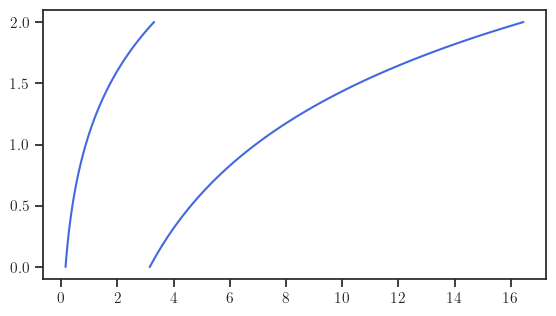

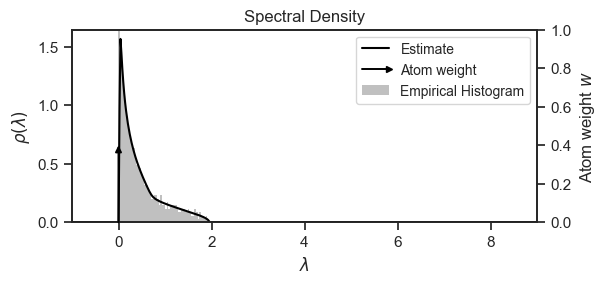

mass: 0.611084


In [30]:
# af = AlgebraicForm(dist)
af = AlgebraicForm(eig_As, delta=1e-5)

deg_m = 3
deg_z = 1

coeffs = af.fit(
    deg_m, deg_z, reg=0, normalize=True, triangular=None,
    mu='auto', mu_reg=0, verbose=True)

# pprint(status)

print('\nSupport:')
est_supp = af.support()
print(est_supp)
print('')

# x = numpy.linspace(x_min, x_max, 500)
x = numpy.linspace(-1, x_max, 500)
rho = af.density(x, plot=True, latex=False)

mass = numpy.trapz(rho, x)
print('mass: %f' % mass)

In [8]:
atoms = af.atoms()
print(atoms)

[(-1.7893033228637894e-15, 0.700000000092926)]


In [9]:
af.coeffs.real

array([[9.99996910e-01, 2.19611171e+00, 8.48347422e-01, 2.16850123e-15],
       [0.00000000e+00, 1.00017611e+00, 2.48228775e+00, 1.21192489e+00]])

In [10]:
status = af.is_decompressible()
print(f'is decompressible: {status}')

is decompressible: True


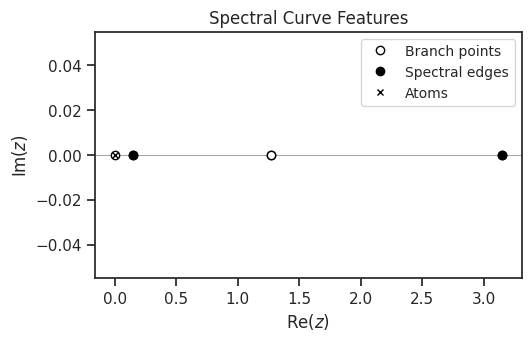

Branch points: [3.15046537e+00 1.27507771e+00 1.27457919e+00 1.52960126e-01
 4.22753258e-15]
Atom location: -0.00
Atom weight: 0.70


In [11]:
# Branch points
bp = af.branch_points(tol=1e-16, real_tol=1e-16, plot=True)
print(f'Branch points: {bp}')

# Atoms
atoms = af.atoms()

for atom_loc, atom_w in atoms:
    print(f'Atom location: {atom_loc:>0.2f}')
    print(f'Atom weight: {atom_w:>0.2f}')

# FD

success rate per t: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1.]


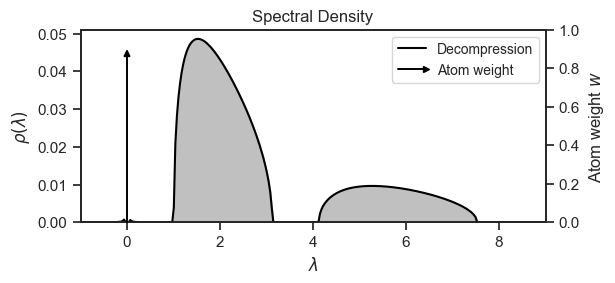

In [31]:
# newton_opt = {'sweep': True}
# newton_opt = {
#     'sweep': True,
#     'sweep_pad': 200,          # much larger than 20
#     'active_imag_eps': 5e-7,   # or ~ 1*eta instead of 50*eta
# }

# -----------------------
# for _decompress.py
# newton_opt = {
#     # 'min_n_times': 50,
#     'sweep': True,
#     'sweep_pad': 30,
#     'active_imag_eps': 1e-6,
# }
# ------------------------
# ---------------------------
## For _decompress4.py
# newton_opt = {
#     "sweep": False,
#     "viterbi_opt": {
#         "lam_space": 1.0,
#         "lam_time": 0.25,
#         "lam_im": 10.0,      # hinge only
#         "edge_k": 12,
#         "lam_asym": 5.0,
#         "lam_norm": 20.0,    # important
#         "refine_newton": True,
#     },
# }

# ---------------------
# newton_opt = {}
# newton_opt = dict(newton_opt)
# newton_opt["eta_hi"] = 3.0
# newton_opt["n_eta"] = 24
# newton_opt["anchor_radius"] = 0.6
# newton_opt["herglotz_tol"] = 0.0  # your convention: Im(m)>0

# newton_opt["viterbi_opt"] = dict(
#     lam_time=0.25,
#     lam_space=1.0,
#     lam_asym=0.2,
#     lam_im2=0.0,     # <-- set to 0 for now
#     edge_k=8,
# )


# ---------------------------

# -------------------------
# For _decompress6.py

# newton_opt = {}
# newton_opt["eta_hi"] = 3.0
# newton_opt["n_eta"] = 24
# newton_opt["anchor_radius"] = 0.6
# newton_opt["herglotz_tol"] = 0.0

# newton_opt["edge_use"] = True
# newton_opt["edge_support"] = est_supp     # <-- from af.fit
# newton_opt["edge_pad"] = 0.0
# newton_opt["im_floor_rel"] = 0.5         # try 0.10–0.30
# newton_opt["w_min"] = 1e-14               # kills the 0j root

# newton_opt["viterbi_opt"] = dict(
#     lam_time=0.25,
#     lam_space=1.0,
#     lam_asym=0.2,
#     lam_im2=0.0,
#     edge_k=8,
# )

# -------------------------

# _defompress7.py
# newton_opt = {}
# newton_opt = dict(
#     max_iter=40, tol=1e-13,
#     damping=1.0, step_clip=5.0,
#     max_split=0,      # IMPORTANT: disable extra intermediate tau tries
#     sweep=False,      # IMPORTANT: avoid bad cross-x seeding
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )

# newton_opt = dict(
#     max_iter=40, tol=1e-13, damping=1.0,
#     step_clip=5.0, max_split=0, sweep=False,
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )

# newton_opt['sweep'] = False
# newton_opt = dict(
#     max_iter=40, tol=1e-13, damping=1.0,
#     step_clip=5.0, max_split=8,      # <--- important
#     require_imw_pos=True, im_eps=1e-14,
#     verbose=False, debug=False,
# )


# Evolve
# rho, x = af.decompress([2000, 3000, 4000, 8000], method='one', newton_opt=newton_opt,
#                     verbose=True, plot=True)
# sizes = numpy.arange(1, 4.1, 0.5)
# sizes = numpy.arange(1, 1.5, 0.05)  # For def MP
# sizes = numpy.arange(1, 1, 0.05)  # For def MP
# sizes = [1.0, 1.01, 1.02, 1.05] 
# sizes = numpy.array([1.0, 1.01])   # smallest step first
# sizes = numpy.arange(1, 1.8, 0.25)
# x = numpy.linspace(0, 12, 100)  # for deformed MP
# x = numpy.linspace(0.5, 9, 100)  # for deformed MP
# x = numpy.linspace(-1, 8, 500)  # for deformed MP
# x = numpy.linspace(-2, 6, 500)
# af.n = As.shape[0]
# x = numpy.linspace(x_min, x_max, 100)

newton_opt = {}
x = numpy.linspace(x_min, x_max, 300)
# x = numpy.linspace(0.01, x_max, 300)
sizes = numpy.arange(As.shape[0], A.shape[0]+1, 500)

rho, x, atoms = af.decompress(
    sizes, x=x, method='moc', min_n_times=100,
    newton_opt=newton_opt, return_atoms=True,
    atom_eps=5e-2,
    verbose=True, plot=True, latex=False)

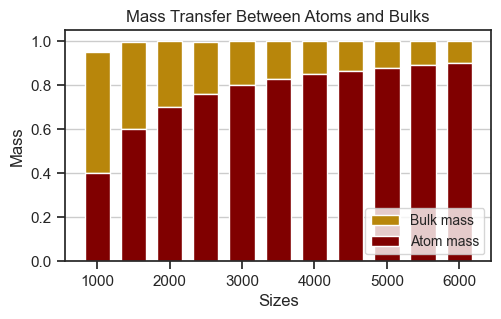

In [32]:
plot_mass(sizes, x, rho, atoms=atoms, gap=0.7, save=False)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-decompress.pdf".


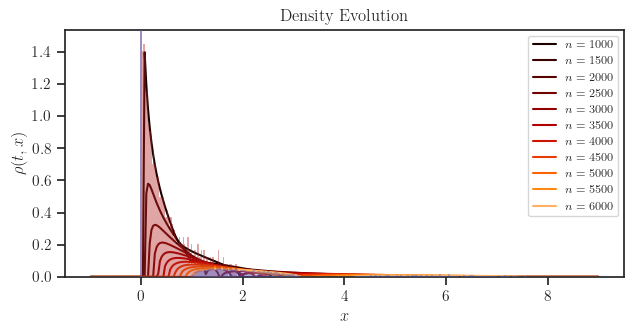

In [33]:
num_plots = rho.shape[0]
cmap = plt.get_cmap('gist_heat')
colors = [cmap(i/(num_plots + 2)) for i in range(num_plots + 1)][1:]

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    
    for i in range(rho.shape[0]):
        ax.plot(x, rho[i], color=colors[i], label=rf'$n={{{sizes[i]}}}$')

    edges, vals = hist(eig_As, 80, atoms=[0], support=af.support())
    ax.stairs(vals, edges, fill=True, zorder=10, alpha=0.4, color='firebrick')

    edges, vals = hist(eig_A, 120, atoms=[0])
    ax.stairs(vals, edges, fill=True, zorder=10, alpha=0.4, color='royalblue')

    # ax.set_xlim([x[0], x[-1]])
    ax.set_ylim([0, 1.1 * numpy.max(rho)])
    # ax.set_ylim([0, 0.8])
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$\rho(t, x)$')
    ax.set_title(r'Density Evolution')
    plt.legend(fontsize='x-small')
    
    plt.tight_layout()
    texplot.show_or_save_plot(plt, default_filename=join(plot_dir, filename + '-decompress.pdf'),
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)

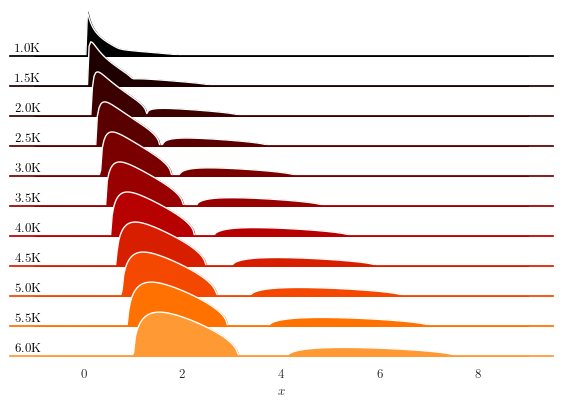

In [34]:
# Ridgeline plot (Also known as Joyplot)

import colorcet as cc

color='royalblue'

num_plots = rho.shape[0]
cmap = plt.get_cmap('gist_heat'); c_min, c_max = 0, 0.8
# cmap = plt.get_cmap('ocean'); c_min, c_max = 0.3, 0.75
# cmap = cc.cm.CET_R4; c_min, c_max = 0, 1.0
# cmap = cc.cm.CET_CBL2; c_min, c_max = 0, 0.5
colors = cmap(numpy.linspace(c_min, c_max, num_plots))

with texplot.theme(use_latex=True):
    fig, ax = plt.subplots(figsize=(7, 4.5), nrows=len(rho), sharex=True)

    fig.patch.set_alpha(0)
    for a in ax:
        a.set_facecolor('none')
    
    for i in range(len(ax)):
        ax[i].fill_between(x, y1=rho[i], y2=0, alpha=1, color=colors[i])

        # mask = rho[i] > 0.01 * numpy.max(rho[i])
        ax[i].plot(x, rho[i], linewidth=1, color='white')
        
        ax[i].text(0.01, 0.09, f'${{{sizes[i]/1000:>.1f}}}$K', color='black',
                   transform=ax[i].transAxes, fontsize=9, ha='left')

        ax[i].set_yticks([])
        ax[i].set_ylim(bottom=0)
        # ax[i].set_ylim([0, 0.2])
        ax[i].spines[['left','right','top']].set_visible(False)
        ax[i].spines["bottom"].set_color(colors[i])

        if i < len(ax) - 1:
            ax[i].tick_params(axis='x', bottom=False, labelbottom=False)
        else:
            ax[i].tick_params(axis='x', bottom=False, labelbottom=True, labelsize=9)

    ax[-1].set_xlabel(r'$x$', fontsize=9)
    fig.subplots_adjust(hspace=-0.35)
    plt.show()

# Edge and Cusp

In [35]:
t_cusp = numpy.linspace(0, 2, 100)
sol = af.cusp(t_cusp)
pprint(sol)
if len(sol) > 0:
    t_cusp = sol[0]['t']
    x_cusp = sol[0]['x']
else:
    t_cusp = None
    x_cusp = None

[{'debug': {'tau': 1.9720781752284746,
            'y': -1.7317178338423753,
            'zeta': 0.6932117121870671},
  'info': {'message': None,
           'norm_inf_F': 2.220446049250313e-16,
           'ok': True,
           'success': True},
  't': 0.6790878980054845,
  'x': 1.2545492212381837}]


In [36]:
t = numpy.linspace(0.0, 2, 100)
complex_edges, real_merged_edges, active_k = af.edge(t, verbose=True)

edge success rate: 1.0


In [37]:
from matplotlib.collections import PolyCollection

# ===============
# fill split bulk
# ===============

def fill_split_bulk(ax, t, edges, color, alpha=0.05, zorder=-2, width_tol=1e-12):
    """
    Seam-free fill for one->two bifurcation using a single PolyCollection.

    Assumes 4 columns layout:
        [a1, a2, b2, b1] where a2,b2 are NaN before split.

    Builds trapezoids between consecutive time samples so there are no
    gaps/overlaps at the cusp.
    """

    t = numpy.asarray(t, dtype=float)
    E = numpy.asarray(edges, dtype=float)

    a1 = E[:, 0]
    a2 = E[:, 1]
    b2 = E[:, 2]
    b1 = E[:, 3]

    polys = []

    def add_strip(i, xL0, xR0, xL1, xR1):
        # Require finite and positive width at both ends
        if not (numpy.isfinite(xL0) and numpy.isfinite(xR0) and numpy.isfinite(xL1) and numpy.isfinite(xR1)):
            return
        if (xR0 - xL0) <= width_tol or (xR1 - xL1) <= width_tol:
            return
        y0 = t[i]
        y1 = t[i+1]
        polys.append([(xL0, y0), (xR0, y0), (xR1, y1), (xL1, y1)])

    for i in range(len(t) - 1):
        # If split edges exist at i and i+1 -> fill two bulks
        split_i  = numpy.isfinite(a2[i])  and numpy.isfinite(b2[i])
        split_ip = numpy.isfinite(a2[i+1]) and numpy.isfinite(b2[i+1])

        if split_i and split_ip:
            # left bulk: [a1, a2]
            add_strip(i, a1[i], a2[i], a1[i+1], a2[i+1])
            # right bulk: [b2, b1]
            add_strip(i, b2[i], b1[i], b2[i+1], b1[i+1])
        else:
            # single bulk: [a1, b1]
            add_strip(i, a1[i], b1[i], a1[i+1], b1[i+1])

    if not polys:
        return

    coll = PolyCollection(
        polys,
        facecolors=[color],
        edgecolors="none",
        closed=True,
        alpha=alpha,
        zorder=zorder)
    
    ax.add_collection(coll)

Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-edge.pdf".


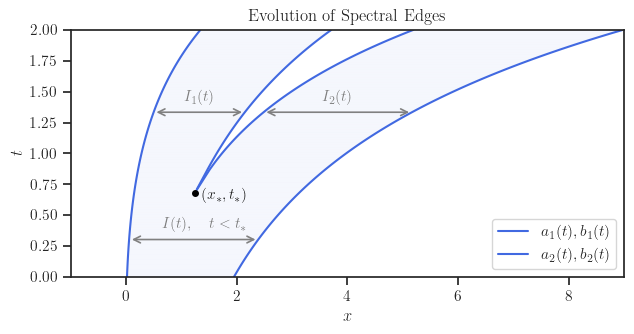

In [38]:
# k = len(support)
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue', 'royalblue']

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.5))
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax.plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax.plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        # m_a = numpy.isnan(a_r)
        # m_b = numpy.isnan(b_r)
        # ax.plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        # ax.plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between (does not work with bifurcation, use fill_split_bulk)
        # ax.fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)
        
        # --------
        # Plot I_j
        # --------
        
        t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.75 * t[-1]
        # t_mid = 0.8 * t[-1]
        j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        ax.annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        ax.text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                fr'$I_{{{j+1}}}(t)$',
                color='gray', ha='center', va='bottom', fontsize=11)

    # Fill between edges includign the bifurcated egdes
    fill_split_bulk(ax, t, real_merged_edges, color='royalblue', alpha=0.05, zorder=-2)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    a_all = real_merged_edges[:, 0]
    b_all = real_merged_edges[:, -1]

    t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    ax.annotate('', xy=(b_all[j_mid2], t[j_mid2]), xytext=(a_all[j_mid2], t[j_mid2]),
                arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    ax.text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
            # r'$I_1(t) \cup I_2(t)$',
            r'$I(t), \quad t < t_{\ast}$',
            color='gray', ha='center', va='bottom', fontsize=11)

    # ---------------------

    # Cusp
    if 't_cusp' in globals():
        ax.plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
        ax.text(x_cusp + 0.12, t_cusp - 0.05, r'$(x_{\ast}, t_{\ast})$', fontsize=11)

    ax.set_xlim([x_min, x_max])
    ax.set_ylim([t[0], t[-1]])
    ax.set_xlabel(r'$x$')
    ax.set_ylabel(r'$t$')
    ax.set_title(r'Evolution of Spectral Edges')
    ax.legend()
    plt.tight_layout()
    
    texplot.show_or_save_plot(plt, default_filename=join(plot_dir, filename + '-edge.pdf'),
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)

# Edge and Histogram

In [39]:
T = numpy.log(sizes[-1] / sizes[0])
t = numpy.linspace(0.0, T, 1000)
complex_edges, real_merged_edges, active_k = af.edge(t, verbose=True)

edge success rate: 1.0


Plot saved to "/home/sia/work/github/freealg/notebooks/./plots/algebraic-compound-poisson-edge-hist.pdf".


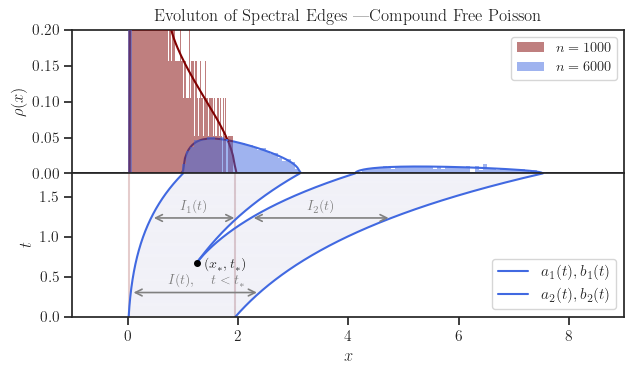

In [40]:
# k = len(support)
k = real_merged_edges.shape[1] // 2

# colors = ['royalblue', 'maroon']
colors = ['royalblue', 'royalblue']

with texplot.theme(use_latex=True):
    
    fig, ax = plt.subplots(figsize=(6.5, 3.9), nrows=2, sharex=True) 

    # Histogram
    ax[0].hist(eig_As, 100, density=True, zorder=10, alpha=0.5, color='maroon',
               edgecolor='none', label=rf'$n = {{{sizes[0]}}}$')
    ax[0].hist(eig_A, 100, density=True, zorder=10, alpha=0.5, color='royalblue',
               edgecolor='none', label=rf'$n = {{{sizes[-1]}}}$')
    
    ax[0].set_xlim([x[0], x[-1]])
    # ax[0].set_ylim(bottom=0)
    ax[0].set_ylim([0, 0.2])
    # ax[0].set_xlabel(r'$x$')
    ax[0].set_ylabel(r'$\rho(x)$')
    ax[0].set_title(r'Evoluton of Spectral Edges |' + title)
    ax[0].legend(fontsize='small')
    # ax[0].tick_params(labelbottom=False)
    ax[0].tick_params(axis='x', bottom=False, labelbottom=False)

    # rho
    # num_plots = rho.shape[0]
    # cmap = plt.get_cmap('gist_heat')
    # colors = [cmap(i/(num_plots + 2)) for i in range(num_plots + 1)][1:]
    ax[0].plot(x, rho[0], color='maroon')
    ax[0].plot(x, rho[-1], color='royalblue')
    
    for j in range(k):
        a_r = real_merged_edges[:, 2*j + 0]
        b_r = real_merged_edges[:, 2*j + 1]

        a_c = complex_edges[:, 2*j + 0].real
        b_c = complex_edges[:, 2*j + 1].real

        # Plot spectral edges with solid lines
        ax[1].plot(a_r, t, color=colors[j], label=rf'$a_{{{j+1}}}(t), b_{{{j+1}}}(t)$')
        ax[1].plot(b_r, t, color=colors[j])

        # Plot ghost edges with dashed lines
        m_a = numpy.isnan(a_r)
        m_b = numpy.isnan(b_r)
        ax[1].plot(a_c[m_a], t[m_a], '--', color=colors[j], alpha=0.25, zorder=-1)
        ax[1].plot(b_c[m_b], t[m_b], '--', color=colors[j], alpha=0.25, zorder=-1)

        # Fill between
        # ax[1].fill_betweenx(t, a_c, b_c, color=colors[j], alpha=0.05, zorder=-2)

        ax[1].axvline(a_c[0], color='maroon',alpha=0.2, zorder=-10)
        ax[1].axvline(b_c[0], color='maroon', alpha=0.2, zorder=-10)
        
        # --------
        # Plot I_j
        # --------
        
        t_mid = 0.5 * (t[-1] - t_cusp) + t_cusp if 't_cusp' in globals() else 0.5 * t[-1]
        j_mid = int(numpy.argmin(numpy.abs(t - t_mid)))
        
        ax[1].annotate('', xy=(float(b_r[j_mid]), t[j_mid]), xytext=(float(a_r[j_mid]), t[j_mid]),
                    arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
        
        ax[1].text(0.5 * (float(a_r[j_mid]) + float(b_r[j_mid])), t[j_mid] + 0.03 * (t[-1] - t[0]),
                fr'$I_{{{j+1}}}(t)$',
                color='gray', ha='center', va='bottom', fontsize=10)

    fill_split_bulk(ax[1], t, real_merged_edges, color='royalblue', alpha=0.05, zorder=-2)

    # ----------------
    # Plot I_1 cup I_2
    # ----------------
    
    a_all = real_merged_edges[:, 0]
    b_all = real_merged_edges[:, -1]

    t_mid2 = 0.45 * min(t_cusp, t[-1]) if 't_cusp' in globals() else 0.45 * t[-1]
    j_mid2 = int(numpy.argmin(numpy.abs(t - t_mid2)))
    
    ax[1].annotate('', xy=(float(b_all[j_mid2]), t[j_mid2]),
                   xytext=(float(a_all[j_mid2]), t[j_mid2]),
                   arrowprops=dict(arrowstyle='<->', color='gray', lw=1.2))
    
    ax[1].text(0.58 * (a_all[j_mid2] + b_all[j_mid2]), t[j_mid2] + 0.03 * (t[-1] - t[0]),
               # r'$I_1(t) \cup I_2(t)$',
               r'$I(t), \quad t < t_{\ast}$',
               color='gray', ha='center', va='bottom', fontsize=10)

    # ----
    # Cusp
    # ----
    
    if 't_cusp' in globals():
        ax[1].plot(x_cusp, t_cusp, 'o', color='black', markersize=4)
        ax[1].text(x_cusp + 0.15, t_cusp - 0.07, r'$(x_{\ast}, t_{\ast})$', fontsize=10)

    ax[1].set_xlim([x_min, x_max])
    ax[1].set_ylim([t[0], t[-1]])
    ax[1].set_xlabel(r'$x$')
    ax[1].set_ylabel(r'$t$')
    # ax[1].set_title(r'Evolution of Spectral Edges')
    ax[1].legend()

    # --------------
    
    plt.tight_layout()
    fig.subplots_adjust(hspace=0.0)
    
    texplot.show_or_save_plot(plt, default_filename=join(plot_dir, filename + '-edge-hist.pdf'),
                              transparent_background=True, dpi=200,
                              show_and_save=True, verbose=True)